<a href="https://colab.research.google.com/github/ananthika123/AI-ML-ICT-Academy/blob/main/heart_disease_supervised_learning_assessment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
# 1. Import libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [74]:
# 2. Load the dataset
df=pd.read_csv("/content/heart_disease.csv")

## Step 1 – Exploratory Data Analysis (EDA)

In [75]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [76]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [78]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [79]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [80]:
#Missing Value
print("\nMissing values:")
display(df.isnull().sum())


Missing values:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [81]:
# 4. Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Remove exact duplicate rows.
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 723
Shape after removing duplicates: (302, 14)


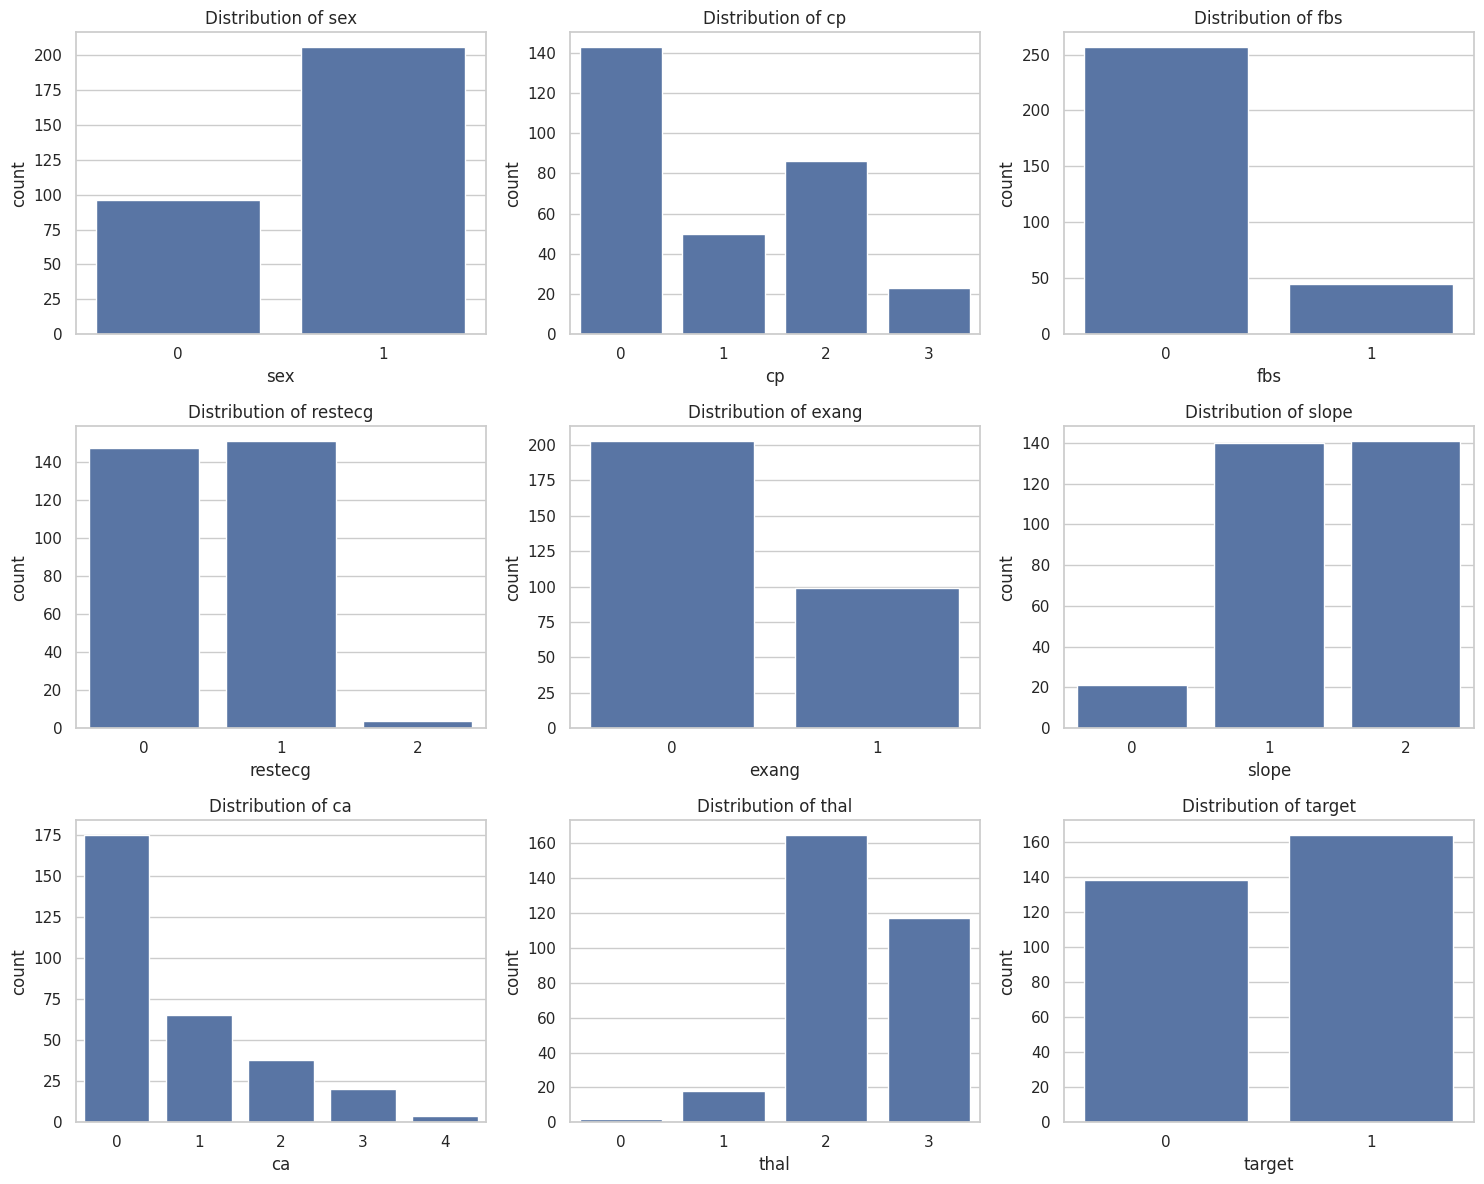

In [82]:
# 6. Visualize categorical distributions

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.ravel(), categorical_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [83]:
# 7. Detect outliers using the IQR method

numeric_cols_all = df.select_dtypes(include=np.number).columns.tolist()

outlier_summary = []

for col in numeric_cols_all:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append([col, q1, q3, lower, upper, count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["column", "Q1", "Q3", "lower_bound", "upper_bound", "outlier_count"]
)

display(outlier_df)

,column,Q1,Q3,lower_bound,upper_bound,outlier_count
0,age,48.00,61.00,28.500,80.500,0
1,sex,0.00,1.00,-1.500,2.500,0
2,cp,0.00,2.00,-3.000,5.000,0
3,trestbps,120.00,140.00,90.000,170.000,9
4,chol,211.00,274.75,115.375,370.375,5
5,fbs,0.00,0.00,0.000,0.000,45
6,restecg,0.00,1.00,-1.500,2.500,0
7,thalach,133.25,166.00,84.125,215.125,1
8,exang,0.00,1.00,-1.500,2.500,0
9,oldpeak,0.00,1.60,-2.400,4.000,5


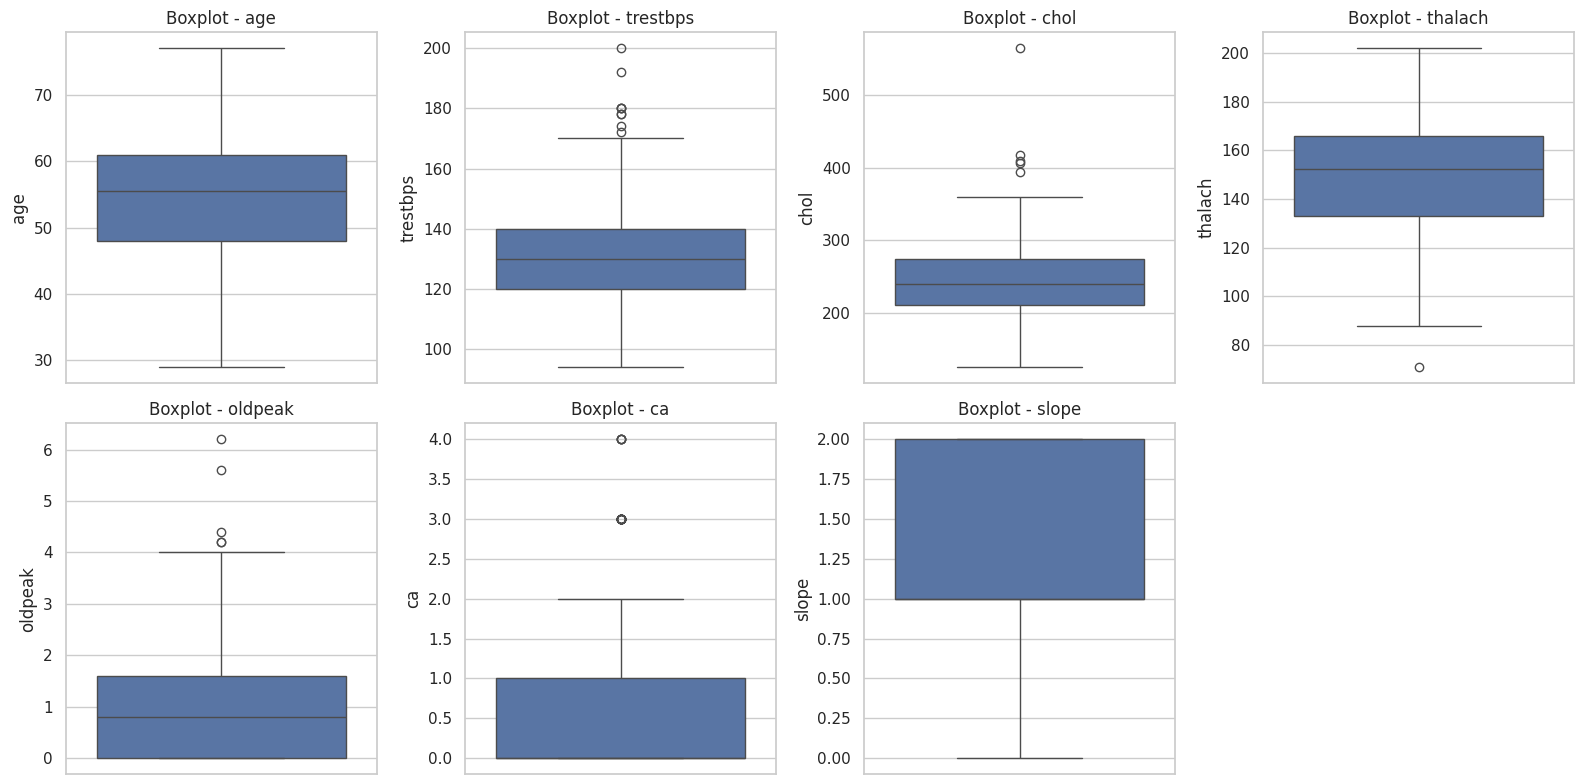

In [84]:
# 8. Boxplots for numerical variables

plot_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "slope"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Boxplot - {col}")

# Hide unused axis
for ax in axes.ravel()[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Step 2 – Data Cleaning and Preprocessing

In [85]:
df = pd.get_dummies(
    df,
    columns=['cp', 'restecg', 'thal'],
    drop_first=True
)

In [86]:
df = df.astype(int)

In [87]:
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1,2,2,0,0,0,0,1,0,0,0,1
1,53,1,140,203,1,155,1,3,0,0,0,0,0,0,0,0,0,0,1
2,70,1,145,174,0,125,1,2,0,0,0,0,0,0,1,0,0,0,1
3,61,1,148,203,0,161,0,0,2,1,0,0,0,0,1,0,0,0,1
4,62,0,138,294,1,106,0,1,1,3,0,0,0,0,1,0,0,1,0


In [88]:
outlier_cols = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

In [89]:
for col in outlier_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
print("Outliers:", ((df[col] < lower) | (df[col] > upper)).sum())


Outliers: 25


In [90]:
for col in outlier_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

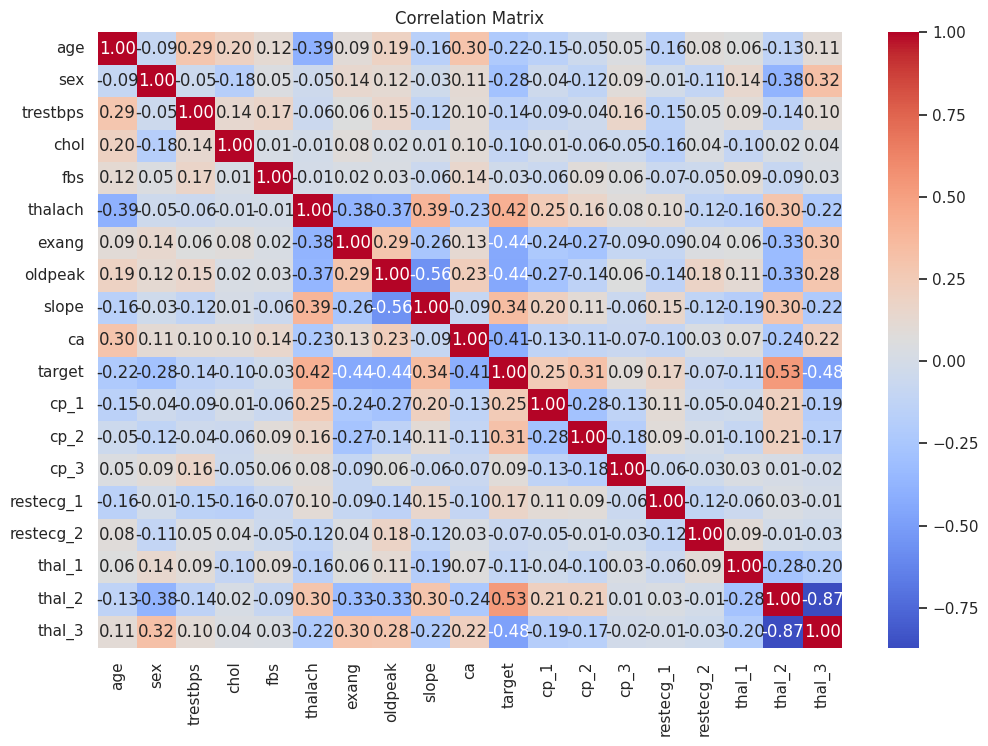

In [91]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [92]:
corr_with_chol = df.corr()['chol'].sort_values(ascending=False)

corr_with_chol

,chol
chol,1.000000
age,0.198901
trestbps,0.135429
ca,0.095374
exang,0.080653
thal_3,0.041580
restecg_2,0.040013
oldpeak,0.024564
thal_2,0.015648
fbs,0.013221


In [93]:
threshold = 0.10

selected_reg_features = corr_with_chol[
    abs(corr_with_chol) >= threshold
].index.tolist()

selected_reg_features.remove('chol')

print("Selected features:")
print(selected_reg_features)

Selected features:
['age', 'trestbps', 'restecg_1', 'sex']


In [94]:
corr_with_target = df.corr()['target'].sort_values(ascending=False)

corr_with_target

,target
target,1.000000
thal_2,0.526030
thalach,0.420408
slope,0.343940
cp_2,0.313696
cp_1,0.247649
restecg_1,0.172827
cp_3,0.087959
fbs,-0.026826
restecg_2,-0.068156


In [95]:
threshold = 0.10

selected_class_features = corr_with_target[
    abs(corr_with_target) >= threshold
].index.tolist()

selected_class_features.remove('target')

print("Selected features:")
print(selected_class_features)

Selected features:
['thal_2', 'thalach', 'slope', 'cp_2', 'cp_1', 'restecg_1', 'thal_1', 'trestbps', 'age', 'sex', 'ca', 'exang', 'oldpeak', 'thal_3']


#Train Test Split

#Regression

In [96]:

X_reg = df[selected_reg_features]
y_reg = df['chol']

In [97]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [98]:
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)

X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [99]:
lr = LinearRegression()

lr.fit(
    X_train_reg_scaled,
    y_train_reg
)

LinearRegression()

In [100]:
svm = SVR()

svm.fit(
    X_train_reg_scaled,
    y_train_reg
)

SVR()

In [101]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_reg.fit(
    X_train_reg,
    y_train_reg
)

RandomForestRegressor(random_state=42)

In [102]:
y_pred_lr = lr.predict(X_test_reg_scaled)
y_pred_svm = svm.predict(X_test_reg_scaled)
y_pred_rf = rf_reg.predict(X_test_reg)

mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("R2:", r2_lr)

mae_svm = mean_absolute_error(y_test_reg, y_pred_svm)
mse_svm = mean_squared_error(y_test_reg, y_pred_svm)
r2_svm = r2_score(y_test_reg, y_pred_svm)

print("SVM")
print("MAE:", mae_svm)
print("MSE:", mse_svm)
print("R2:", r2_svm)

mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R2:", r2_rf)

Linear Regression
MAE: 32.98586239301848
MSE: 1723.3434065194772
R2: -0.07706083059627811
SVM
MAE: 31.23889689679586
MSE: 1558.53286650866
R2: 0.025943002791507852
Random Forest
MAE: 38.65458697632058
MSE: 2414.8643560853952
R2: -0.5092498681940942


In [103]:
regression_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'SVM',
        'Random Forest'
    ],
    'MAE': [
        mae_lr,
        mae_svm,
        mae_rf
    ],
    'MSE': [
        mse_lr,
        mse_svm,
        mse_rf
    ],
    'R2': [
        r2_lr,
        r2_svm,
        r2_rf
    ]
})

regression_results

,Model,MAE,MSE,R2
0,Linear Regression,32.985862,1723.343407,-0.077061
1,SVM,31.238897,1558.532867,0.025943
2,Random Forest,38.654587,2414.864356,-0.509250


In [104]:
best_regression = regression_results.loc[
    regression_results['R2'].idxmax()
]

print("Best Regression Model:")
print(best_regression)

Best Regression Model:
Model            SVM
MAE        31.238897
MSE      1558.532867
R2          0.025943
Name: 1, dtype: object


#Classification

In [105]:

X_class = df[selected_class_features]
y_class = df['target']

In [106]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

In [107]:
scaler_class = StandardScaler()

X_train_class_scaled = scaler_class.fit_transform(X_train_class)

X_test_class_scaled = scaler_class.transform(X_test_class)

In [108]:
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_class_scaled,
    y_train_class
)

LogisticRegression(max_iter=1000)

In [109]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_class_scaled,
    y_train_class
)

KNeighborsClassifier()

In [110]:
rf_class = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_class.fit(
    X_train_class,
    y_train_class
)

RandomForestClassifier(random_state=42)

In [111]:
y_pred_log = log_model.predict(X_test_class_scaled)
y_pred_knn = knn.predict(X_test_class_scaled)
y_pred_rf = rf_class.predict(X_test_class)

accuracy_log = accuracy_score(y_test_class, y_pred_log)
precision_log = precision_score(y_test_class, y_pred_log)
recall_log = recall_score(y_test_class, y_pred_log)
f1_log = f1_score(y_test_class, y_pred_log)

print("Logistic Regression")
print("Accuracy:", accuracy_log)
print("Precision:", precision_log)
print("Recall:", recall_log)
print("F1 Score:", f1_log)

accuracy_knn = accuracy_score(y_pred_knn, y_test_class)
precision_knn = precision_score(y_pred_knn, y_test_class)
recall_knn = recall_score(y_pred_knn, y_test_class)
f1_knn = f1_score(y_pred_knn, y_test_class)

print("KNN")
print("Accuracy:", accuracy_knn)
print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1 Score:", f1_knn)

accuracy_rf = accuracy_score(y_pred_rf, y_test_class)
precision_rf = precision_score(y_pred_rf, y_test_class)
recall_rf = recall_score(y_pred_rf, y_test_class)
f1_rf = f1_score(y_pred_rf, y_test_class)

print("Random Forest")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)

Logistic Regression
Accuracy: 0.8360655737704918
Precision: 0.8484848484848485
Recall: 0.8484848484848485
F1 Score: 0.8484848484848485
KNN
Accuracy: 0.8032786885245902
Precision: 0.7878787878787878
Recall: 0.8387096774193549
F1 Score: 0.8125
Random Forest
Accuracy: 0.8032786885245902
Precision: 0.8181818181818182
Recall: 0.8181818181818182
F1 Score: 0.8181818181818182


In [112]:
classification_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_log,
        accuracy_knn,
        accuracy_rf
    ],
    'Precision': [
        precision_log,
        precision_knn,
        precision_rf
    ],
    'Recall': [
        recall_log,
        recall_knn,
        recall_rf
    ],
    'F1 Score': [
        f1_log,
        f1_knn,
        f1_rf
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.836066,0.848485,0.848485,0.848485
1,KNN,0.803279,0.787879,0.838710,0.812500
2,Random Forest,0.803279,0.818182,0.818182,0.818182


In [113]:
best_classification = classification_results.loc[
    classification_results['Recall'].idxmax()
]

print("Best Classification Model:")
print(best_classification)

Best Classification Model:
Model        Logistic Regression
Accuracy                0.836066
Precision               0.848485
Recall                  0.848485
F1 Score                0.848485
Name: 0, dtype: object


In [114]:
print("========== REGRESSION RESULTS ==========")
display(regression_results)

print("\n========== CLASSIFICATION RESULTS ==========")
display(classification_results)

print("\n========== BEST REGRESSION MODEL ==========")
print(best_regression['Model'])

print("\n========== BEST CLASSIFICATION MODEL ==========")
print(best_classification['Model'])

========== REGRESSION RESULTS ==========


,Model,MAE,MSE,R2
0,Linear Regression,32.985862,1723.343407,-0.077061
1,SVM,31.238897,1558.532867,0.025943
2,Random Forest,38.654587,2414.864356,-0.509250



========== CLASSIFICATION RESULTS ==========


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.836066,0.848485,0.848485,0.848485
1,KNN,0.803279,0.787879,0.838710,0.812500
2,Random Forest,0.803279,0.818182,0.818182,0.818182



========== BEST REGRESSION MODEL ==========
SVM

========== BEST CLASSIFICATION MODEL ==========
Logistic Regression


#Conclusion

In this assessment, the heart disease dataset was analyzed and preprocessed by checking missing values, data types, summary statistics, categorical distributions, and outliers. Missing values were handled where required, numerical outliers were treated using the IQR method, and categorical variables were encoded using one-hot encoding and binary representation.

For the regression task, serum cholesterol (chol) was used as the target variable. Linear Regression, SVM, and Random Forest Regression models were trained and evaluated using MAE, MSE, and R². The model with the highest R² was selected as the best regression model.

For the classification task, target was used to predict the presence of heart disease. Logistic Regression, KNN, and Random Forest Classifier were trained and evaluated using Accuracy, Precision, Recall, and F1-score. The model with the highest Recall was selected as the best classification model.